C:\Users\whdal\AppData\Local\Temp\ipykernel_28872\2578697957.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['IdMax'] = pd.to_numeric(df['IdMax'], errors='coerce')
C:\Users\whdal\AppData\Local\Temp\ipykernel_28872\2578697957.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['block'] = df['IdMax'].notna().cumsum()
C:\Users\whdal\AppData\Local\Temp\ipykernel_28872\2578697957.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

    Vgate Vdrain        Idrain         IdMax  time_s
0   -3.00    0.1  1.200000e-13  7.788210e-09   15000
1   -2.95    0.1  6.790000e-13           NaN   15000
2   -2.90    0.1  6.350000e-13           NaN   15000
3   -2.85    0.1  6.600000e-13           NaN   15000
4   -2.80    0.1  7.310000e-13           NaN   15000
5   -2.75    0.1  6.240000e-13           NaN   15000
6   -2.70    0.1  5.860000e-13           NaN   15000
7   -2.65    0.1  6.860000e-13           NaN   15000
8   -2.60    0.1  6.920000e-13           NaN   15000
9   -2.55    0.1  6.820000e-13           NaN   15000
10  -2.50    0.1  7.190000e-13           NaN   15000
11  -2.45    0.1  5.720000e-13           NaN   15000
12  -2.40    0.1  6.510000e-13           NaN   15000
13  -2.35    0.1  6.360000e-13           NaN   15000
14  -2.30    0.1  7.000000e-13           NaN   15000
15  -2.25    0.1  6.720000e-13           NaN   15000
16  -2.20    0.1  7.350000e-13           NaN   15000
17  -2.15    0.1  6.960000e-13           NaN  

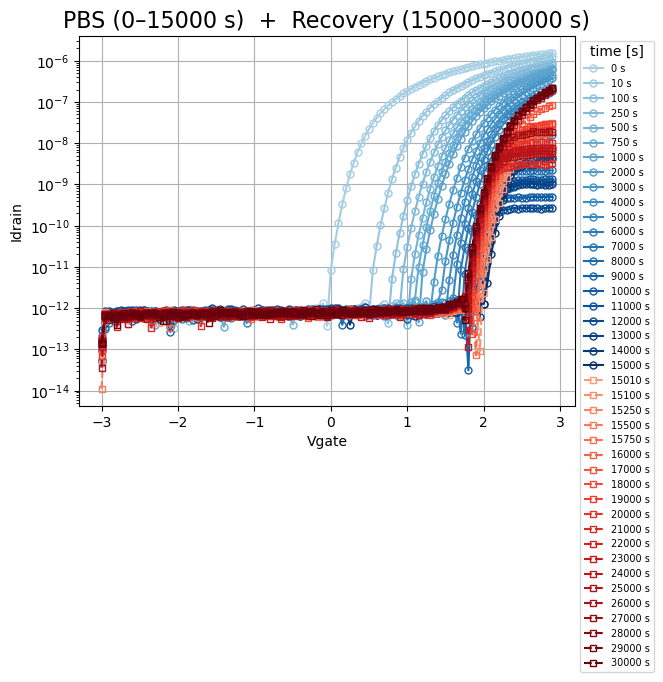

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv


def load_pbs_csv(filepath):
    rows = []
    with open(filepath, "r", encoding="utf-8-sig", errors="replace", newline="") as f:
        reader = csv.reader(f)
        for r in reader:
            rows.append(r)

    max_len = max(len(r) for r in rows)
    rows = [r + [""] * (max_len - len(r)) for r in rows]

    raw_data = pd.DataFrame(rows)
    raw_data = raw_data[raw_data[0].isin(['DataValue'])]
    raw_data = raw_data.iloc[:, 1:6]
    raw_data.columns = ['Vgate', 'Vdrain', 'Idrain', 'IdMax', 'Vth@Id']

    df = raw_data
    time = df.loc[df['Idrain'].isin([' ']), 'Vgate']
    time_list = list(reversed(time.tolist()))
    time_count = len(time_list)
    df = df.iloc[time_count:, :]

    df['IdMax'] = pd.to_numeric(df['IdMax'], errors='coerce')
    df['block'] = df['IdMax'].notna().cumsum()
    df = df[df['block'] > 0].copy()

    mapping = {i + 1: t for i, t in enumerate(time_list)}
    df['time_s'] = df['block'].map(mapping)

    df['Vgate']  = pd.to_numeric(df['Vgate'],  errors='coerce')
    df['Idrain'] = pd.to_numeric(df['Idrain'], errors='coerce').abs()
    df['time_s'] = pd.to_numeric(df['time_s'], errors='coerce')

    return df


# PBS stress: 0 ~ 15000 s
path  = "PBTI_IGZO_new2 [260331_WF02_#2_MID_UNITTR_PBS_VG4.5V_15ks_R9(19) ; 4_17_2026 2_23_01 PM].csv"
# Recovery: 실험 직후 측정, 시간축을 15000 s offset 하여 15000 ~ 30000 s 로 표기
path1 = "PBTI_IGZO_new2 [260331_WF02_#2_MID_UNITTR_PBS_VG0V_15ks_R9(20) ; 4_17_2026 6_37_40 PM].csv"

STRESS_DURATION = 15000  # PBS stress 종료 시간 [s]

df_stress = load_pbs_csv(path)

df_recovery = load_pbs_csv(path1)
df_recovery['time_s'] = df_recovery['time_s'] + STRESS_DURATION
# path1의 t=0 (offset 후 15000 s)은 path의 t=15000 과 중복되므로 제거
df_recovery = df_recovery[df_recovery['time_s'] > STRESS_DURATION]

df = pd.concat([df_stress, df_recovery], ignore_index=True)

print(df[['Vgate', 'Vdrain', 'Idrain', 'IdMax', 'time_s']].head(30))

plot_df = df.dropna(subset=['Vgate', 'Idrain', 'time_s']).copy()
times = sorted(plot_df['time_s'].unique())

stress_times   = [t for t in times if t <= STRESS_DURATION]
recovery_times = [t for t in times if t >  STRESS_DURATION]

cmap_s = plt.cm.Blues(np.linspace(0.35, 1.0, max(len(stress_times),   1)))
cmap_r = plt.cm.Reds( np.linspace(0.35, 1.0, max(len(recovery_times), 1)))

plt.figure()
for i, t in enumerate(stress_times):
    d = plot_df[plot_df['time_s'] == t].sort_values('Vgate')
    plt.semilogy(d['Vgate'].to_numpy(), d['Idrain'].to_numpy(),
                 marker='o', markerfacecolor='none', markersize=5, linestyle='-',
                 color=cmap_s[i], label=f'{int(t)} s')

for i, t in enumerate(recovery_times):
    d = plot_df[plot_df['time_s'] == t].sort_values('Vgate')
    plt.semilogy(d['Vgate'].to_numpy(), d['Idrain'].to_numpy(),
                 marker='s', markerfacecolor='none', markersize=5, linestyle='--',
                 color=cmap_r[i], label=f'{int(t)} s')

plt.xlabel('Vgate')
plt.ylabel('Idrain')
plt.title('PBS (0–15000 s)  +  Recovery (15000–30000 s)', fontsize=16)
plt.legend(title='time [s]', bbox_to_anchor=(1, 1), loc='upper left', fontsize=7)
plt.grid(True)
plt.show()


In [8]:
W_um = 40
L_um = 20
W_over_L = W_um / L_um

# constant current method? Id/(W/L) ???? ??
target1 = -10  # log10(|Id|/(W/L)) = -10 ??? Vth
target2 = -9   # SS ???: ??? ?? 10? ?? ??

vth_by_time_10 = {}
vth_by_time_9 = {}

for vd, g in df.groupby('time_s'):
    g = g.sort_values('Idrain')

    VG = g['Vgate'].to_numpy()
    ID = g['Idrain'].to_numpy()

    absID = np.abs(ID)
    absID = np.clip(absID, 1e-300, None)
    normID = absID / W_over_L
    logI_norm = np.log10(normID)

    diff1 = logI_norm - target1
    diff2 = logI_norm - target2
    cross_idx_10 = np.where(diff1[:-1] * diff1[1:] <= 0)[0]
    cross_idx_9 = np.where(diff2[:-1] * diff2[1:] <= 0)[0]

    vth_by_time_10[vd] = np.nan
    vth_by_time_9[vd] = np.nan

    if len(cross_idx_10) == 0:
        continue

    i1 = cross_idx_10[0]

    x0, x1 = VG[i1], VG[i1 + 1]
    y0, y1 = logI_norm[i1], logI_norm[i1 + 1]

    if y1 == y0:
        vth_10 = np.nan
    else:
        vth_10 = x0 + (target1 - y0) * (x1 - x0) / (y1 - y0)

    vth_by_time_10[vd] = vth_10

    if len(cross_idx_9) == 0:
        continue

    i2 = cross_idx_9[0]
    z0, z1 = VG[i2], VG[i2 + 1]
    t0, t1 = logI_norm[i2], logI_norm[i2 + 1]

    if t1 == t0:
        vth_9 = np.nan
    else:
        vth_9 = z0 + (target2 - t0) * (z1 - z0) / (t1 - t0)

    vth_by_time_9[vd] = vth_9

print(f'W/L = {W_over_L:.2f}')
print(f'Vth criterion: log10(|Id|/(W/L)) = {target1}')
for vd in sorted(vth_by_time_10.keys()):
    print(f'times={vd}[s]: Vth={vth_by_time_10[vd]:.2f}')

ss_by_vd = {}

for vd in vth_by_time_10.keys():
    vg_at_10 = vth_by_time_10.get(vd, np.nan)
    vg_at_9 = vth_by_time_9.get(vd, np.nan)

    if np.isnan(vg_at_10) or np.isnan(vg_at_9):
        ss_by_vd[vd] = np.nan
    else:
        ss_v_per_dec = (vg_at_9 - vg_at_10) / (target2 - target1)
        ss_by_vd[vd] = ss_v_per_dec * 1000

print(f'SS (mV/dec) using log10(|Id|/(W/L)) = {target1} to {target2}')
for vd in sorted(ss_by_vd.keys()):
    print(f'times={vd}[s]: Vth={vth_by_time_10[vd]:.2f}, SS={ss_by_vd[vd]:.2f}')


W/L = 2.00
Vth criterion: log10(|Id|/(W/L)) = -10
times=0[s]: Vth=0.13
times=10[s]: Vth=0.69
times=100[s]: Vth=0.96
times=250[s]: Vth=1.09
times=500[s]: Vth=1.21
times=750[s]: Vth=1.29
times=1000[s]: Vth=1.35
times=2000[s]: Vth=1.52
times=3000[s]: Vth=1.63
times=4000[s]: Vth=1.71
times=5000[s]: Vth=1.78
times=6000[s]: Vth=1.85
times=7000[s]: Vth=1.91
times=8000[s]: Vth=1.95
times=9000[s]: Vth=2.00
times=10000[s]: Vth=2.05
times=11000[s]: Vth=2.08
times=12000[s]: Vth=2.17
times=13000[s]: Vth=2.15
times=14000[s]: Vth=2.18
times=15000[s]: Vth=2.21
times=15010[s]: Vth=2.17
times=15100[s]: Vth=2.13
times=15250[s]: Vth=2.11
times=15500[s]: Vth=2.09
times=15750[s]: Vth=2.08
times=16000[s]: Vth=2.07
times=17000[s]: Vth=2.04
times=18000[s]: Vth=2.02
times=19000[s]: Vth=2.01
times=20000[s]: Vth=2.00
times=21000[s]: Vth=1.99
times=22000[s]: Vth=1.98
times=23000[s]: Vth=1.98
times=24000[s]: Vth=1.97
times=25000[s]: Vth=1.96
times=26000[s]: Vth=1.96
times=27000[s]: Vth=1.95
times=28000[s]: Vth=1.94

In [3]:
print(df)

      Vgate Vdrain        Idrain         IdMax Vth@Id  block  time_s
0     -3.00    0.1  1.200000e-13  7.788210e-09    2.9      1   15000
1     -2.95    0.1  6.790000e-13           NaN    2.9      1   15000
2     -2.90    0.1  6.350000e-13           NaN    2.9      1   15000
3     -2.85    0.1  6.600000e-13           NaN    2.9      1   15000
4     -2.80    0.1  7.310000e-13           NaN    2.9      1   15000
...     ...    ...           ...           ...    ...    ...     ...
4874   2.70    0.1  6.935030e-09           NaN    2.9     20   15010
4875   2.75    0.1  7.219080e-09           NaN    2.9     20   15010
4876   2.80    0.1  7.593260e-09           NaN    2.9     20   15010
4877   2.85    0.1  7.636250e-09           NaN    2.9     20   15010
4878   2.90    0.1  7.751290e-09           NaN    2.9     20   15010

[4879 rows x 7 columns]


Delta Vth reference: time=0[s], Vth=0.13 V
time=0[s]: Delta Vth=0.00 V
time=10[s]: Delta Vth=0.56 V
time=100[s]: Delta Vth=0.83 V
time=250[s]: Delta Vth=0.97 V
time=500[s]: Delta Vth=1.09 V
time=750[s]: Delta Vth=1.17 V
time=1000[s]: Delta Vth=1.23 V
time=2000[s]: Delta Vth=1.39 V
time=3000[s]: Delta Vth=1.50 V
time=4000[s]: Delta Vth=1.59 V
time=5000[s]: Delta Vth=1.66 V
time=6000[s]: Delta Vth=1.72 V
time=7000[s]: Delta Vth=1.78 V
time=8000[s]: Delta Vth=1.82 V
time=9000[s]: Delta Vth=1.87 V
time=10000[s]: Delta Vth=1.93 V
time=11000[s]: Delta Vth=1.95 V
time=12000[s]: Delta Vth=2.05 V
time=13000[s]: Delta Vth=2.02 V
time=14000[s]: Delta Vth=2.05 V
time=15000[s]: Delta Vth=2.08 V
time=15010[s]: Delta Vth=2.04 V
time=15100[s]: Delta Vth=2.01 V
time=15250[s]: Delta Vth=1.98 V
time=15500[s]: Delta Vth=1.96 V
time=15750[s]: Delta Vth=1.95 V
time=16000[s]: Delta Vth=1.94 V
time=17000[s]: Delta Vth=1.91 V
time=18000[s]: Delta Vth=1.90 V
time=19000[s]: Delta Vth=1.88 V
time=20000[s]: Delta 

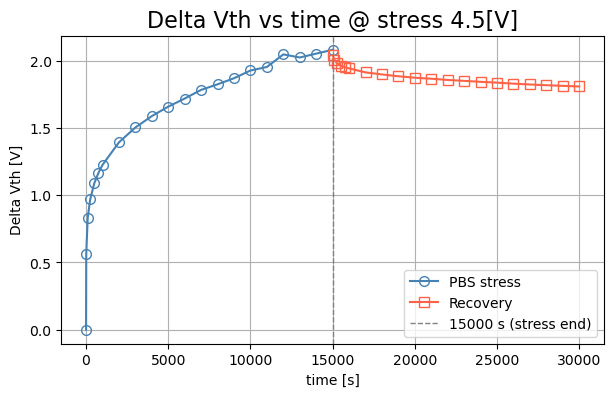

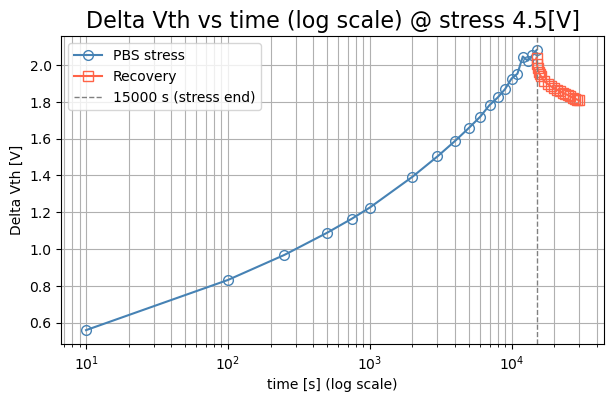

In [9]:
# time별 Delta Vth 계산 및 그래프
delta_vth_ref_time = min(vth_by_time_10.keys())
delta_vth_ref_value = vth_by_time_10[delta_vth_ref_time]

delta_vth_by_time = {}
for t in sorted(vth_by_time_10.keys()):
    vth_val = vth_by_time_10[t]
    if np.isnan(vth_val) or np.isnan(delta_vth_ref_value):
        delta_vth_by_time[t] = np.nan
    else:
        delta_vth_by_time[t] = vth_val - delta_vth_ref_value

delta_vth_df = pd.DataFrame({
    'time_s':    sorted(delta_vth_by_time.keys()),
    'delta_vth': [delta_vth_by_time[t] for t in sorted(delta_vth_by_time.keys())]
})

print(f"Delta Vth reference: time={delta_vth_ref_time}[s], Vth={delta_vth_ref_value:.2f} V")
for _, row in delta_vth_df.iterrows():
    print(f"time={int(row['time_s'])}[s]: Delta Vth={row['delta_vth']:.2f} V")

def _split(df_in):
    sm = df_in['time_s'] <= STRESS_DURATION
    return df_in[sm], df_in[~sm]

# --- linear scale ---
s_lin, r_lin = _split(delta_vth_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(s_lin['time_s'], s_lin['delta_vth'],
        marker='o', markerfacecolor='none', markersize=7, linewidth=1.5,
        color='steelblue', label='PBS stress')
ax.plot(r_lin['time_s'], r_lin['delta_vth'],
        marker='s', markerfacecolor='none', markersize=7, linewidth=1.5,
        color='tomato', label='Recovery')
ax.axvline(STRESS_DURATION, color='gray', linestyle='--', linewidth=1,
           label=f'{STRESS_DURATION} s (stress end)')
ax.set_xlabel('time [s]')
ax.set_ylabel('Delta Vth [V]')
ax.set_title('Delta Vth vs time @ stress 4.5[V]', fontsize=16)
ax.legend()
ax.grid(True)
plt.show()

# --- log scale (t=0 제외) ---
delta_vth_df_log = delta_vth_df[delta_vth_df['time_s'] > 0].copy()
s_log, r_log = _split(delta_vth_df_log)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(s_log['time_s'], s_log['delta_vth'],
        marker='o', markerfacecolor='none', markersize=7, linewidth=1.5,
        color='steelblue', label='PBS stress')
ax.plot(r_log['time_s'], r_log['delta_vth'],
        marker='s', markerfacecolor='none', markersize=7, linewidth=1.5,
        color='tomato', label='Recovery')
ax.axvline(STRESS_DURATION, color='gray', linestyle='--', linewidth=1,
           label=f'{STRESS_DURATION} s (stress end)')
ax.set_xscale('log')
ax.set_xlabel('time [s] (log scale)')
ax.set_ylabel('Delta Vth [V]')
ax.set_title('Delta Vth vs time (log scale) @ stress 4.5[V]', fontsize=16)
ax.legend()
ax.grid(True, which='both')
plt.show()


Stretched exponential fit results  (PBS stress only)
v_pre = 9.7156 V
tau   = 6956733.04 s
beta  = 0.2583
v_inf = 9.9999 V
R^2   = 0.9987


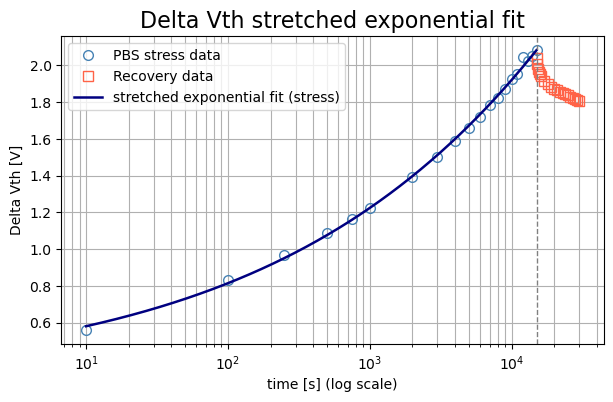

In [5]:
from scipy.optimize import curve_fit

def stretched_exponential(t, v_pre, tau, beta, v_inf):
    return -v_pre * np.exp(-((t / tau) ** beta)) + v_inf

# Stretched exponential fit은 PBS stress 구간(0 < t <= STRESS_DURATION)만 사용
fit_df = delta_vth_df[
    (delta_vth_df['time_s'] > 0) &
    (delta_vth_df['time_s'] <= STRESS_DURATION) &
    delta_vth_df['delta_vth'].notna()
].copy()

x_fit = fit_df['time_s'].to_numpy(dtype=float)
y_fit = fit_df['delta_vth'].to_numpy(dtype=float)

p0 = [max(y_fit.max() - y_fit.min(), 1e-3), np.median(x_fit), 0.5, y_fit.max()]
bounds = ([0, 1e-9, 0.05, 0], [10, 1e8, 1.5, 10])

popt, pcov = curve_fit(
    stretched_exponential,
    x_fit,
    y_fit,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)

v_pre_fit, tau_fit, beta_fit, v_inf_fit = popt
y_pred = stretched_exponential(x_fit, *popt)
r2 = 1 - np.sum((y_fit - y_pred) ** 2) / np.sum((y_fit - y_fit.mean()) ** 2)

print('Stretched exponential fit results  (PBS stress only)')
print(f'v_pre = {v_pre_fit:.4f} V')
print(f'tau   = {tau_fit:.2f} s')
print(f'beta  = {beta_fit:.4f}')
print(f'v_inf = {v_inf_fit:.4f} V')
print(f'R^2   = {r2:.4f}')

t_dense = np.logspace(np.log10(x_fit.min()), np.log10(x_fit.max()), 400)
y_dense = stretched_exponential(t_dense, *popt)

all_log = delta_vth_df[delta_vth_df['time_s'] > 0].copy()
s_all, r_all = _split(all_log)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(s_all['time_s'], s_all['delta_vth'],
        'o', markerfacecolor='none', markersize=7, color='steelblue', label='PBS stress data')
ax.plot(r_all['time_s'], r_all['delta_vth'],
        's', markerfacecolor='none', markersize=7, color='tomato', label='Recovery data')
ax.plot(t_dense, y_dense, '-', linewidth=1.8, color='navy',
        label='stretched exponential fit (stress)')
ax.axvline(STRESS_DURATION, color='gray', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('time [s] (log scale)')
ax.set_ylabel('Delta Vth [V]')
ax.set_title('Delta Vth stretched exponential fit', fontsize=16)
ax.grid(True, which='both')
ax.legend()
plt.show()


channel area = 8.0000e-06 cm^2
Cox_total = 4.2500e-12 pF
Cox_areal = 5.3125e-19 F/cm^2


,time_s,phase,Vth_V,Delta_Vth_V,SS_mV_dec,peak_gm_S,Vg_at_peak_gm_V,Ion_A,Ioff_A,Ion_Ioff_ratio,Id_at_Vov_1.0V_A,Idsat_at_Vg_2.0V_A,Vd_linear_V,mu_FE_peak_cm2_Vs,mu_FE_at_Vov_1.0V_cm2_Vs
0,0,stress,0.126494,0.000000,133.967099,7.978000e-07,2.80,1.548340e-06,2.890000e-13,5.357578e+06,2.494584e-07,8.504450e-07,0.1,7.508706e+12,5.141701e+12
1,10,stress,0.685851,0.559357,144.944544,9.918000e-07,2.90,1.229590e-06,1.020000e-13,1.205480e+07,2.404440e-07,4.419390e-07,0.1,9.334588e+12,5.247825e+12
2,100,stress,0.958471,0.831977,152.441687,9.134400e-07,2.90,9.369420e-07,9.900000e-14,9.464061e+06,2.260036e-07,2.488020e-07,0.1,8.597082e+12,5.063908e+12
3,250,stress,1.094589,0.968095,154.645944,8.123800e-07,2.85,7.768180e-07,1.670000e-13,4.651605e+06,2.183482e-07,1.717340e-07,0.1,7.645929e+12,4.889661e+12
4,500,stress,1.214972,1.088478,157.869427,7.319800e-07,2.90,6.503460e-07,1.640000e-13,3.965524e+06,2.126626e-07,1.169920e-07,0.1,6.889224e+12,4.733719e+12
5,750,stress,1.291987,1.165493,157.738416,7.953600e-07,2.90,6.243950e-07,4.600000e-14,1.357380e+07,2.148891e-07,8.960120e-08,0.1,7.485741e+12,4.899775e+12
6,1000,stress,1.351837,1.225342,159.041461,7.788400e-07,2.90,5.781700e-07,2.270000e-13,2.547004e+06,2.143319e-07,7.047920e-08,0.1,7.330259e+12,4.899894e+12
7,2000,stress,1.519409,1.392915,159.306819,7.043400e-07,2.90,4.495720e-07,1.790000e-13,2.511575e+06,2.131059e-07,3.098030e-08,0.1,6.629082e+12,4.874334e+12
8,3000,stress,1.629921,1.503426,158.739406,6.493800e-07,2.90,3.727860e-07,1.130000e-13,3.298991e+06,2.131289e-07,1.520740e-08,0.1,6.111812e+12,4.855912e+12
9,4000,stress,1.714568,1.588073,158.651468,2.891400e-07,2.65,2.102120e-07,5.300000e-14,3.966264e+06,1.595565e-07,7.549930e-09,0.1,2.721318e+12,2.643728e+12


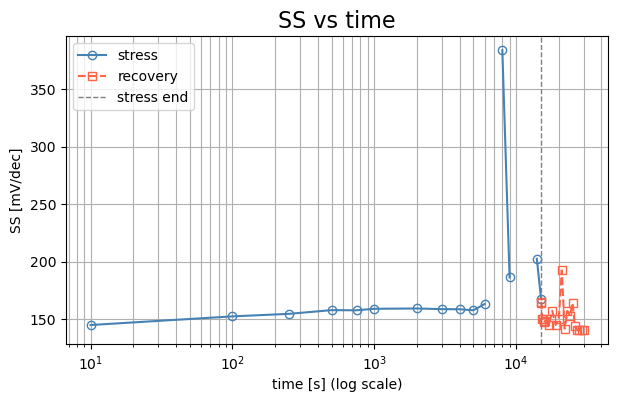

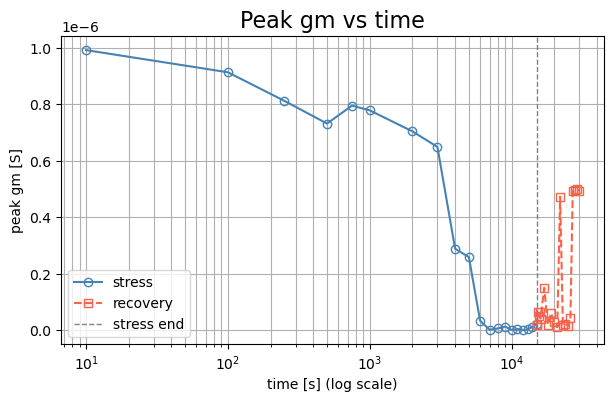

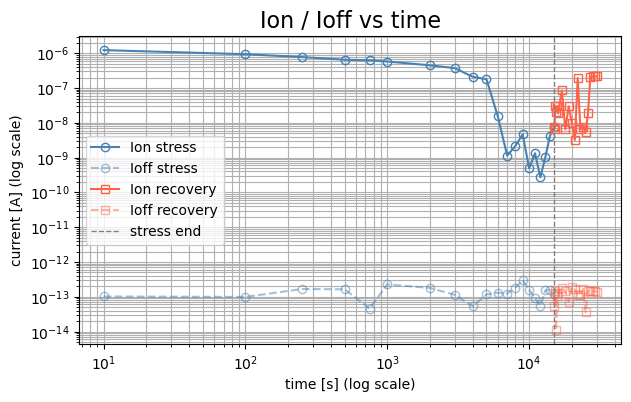

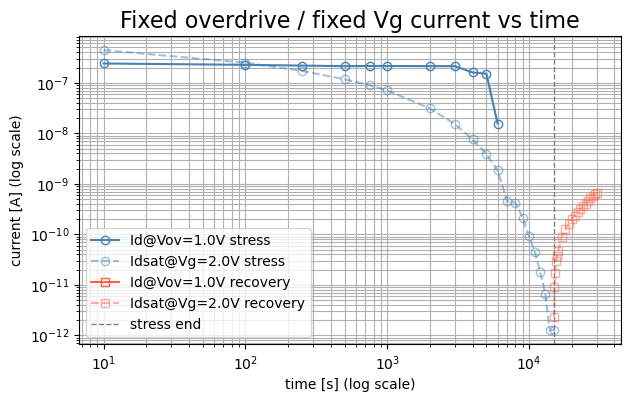

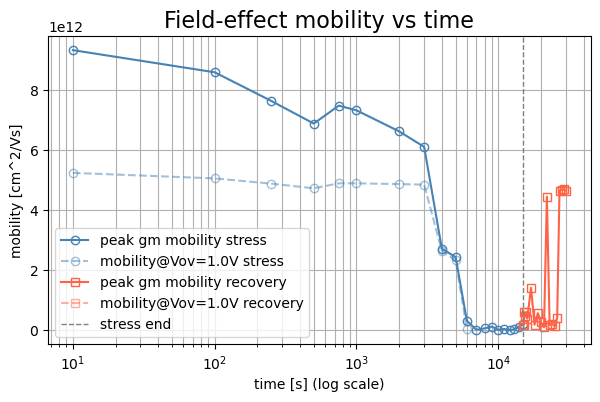

In [6]:
# 원인 분리를 위한 지표 정리
overdrive_v = 1.0
fixed_vg_for_idsat = 2.0
cox_total_pf = 4.25e-12

w_cm = W_um * 1e-4
l_cm = L_um * 1e-4
channel_area_cm2 = w_cm * l_cm
cox_total_f = cox_total_pf * 1e-12 if not np.isnan(cox_total_pf) else np.nan
cox_f_per_cm2 = cox_total_f / channel_area_cm2 if not np.isnan(cox_total_f) else np.nan

print(f'channel area = {channel_area_cm2:.4e} cm^2')
print(f'Cox_total = {cox_total_pf:.4e} pF')
print(f'Cox_areal = {cox_f_per_cm2:.4e} F/cm^2')

metric_rows = []

for t in sorted(plot_df['time_s'].unique()):
    g = plot_df[plot_df['time_s'] == t].sort_values('Vgate').copy()

    vg = g['Vgate'].to_numpy(dtype=float)
    vd = g['Vdrain'].to_numpy(dtype=float)
    id_abs = g['Idrain'].to_numpy(dtype=float)
    gm = np.gradient(id_abs, vg)
    vd_linear_v = float(np.nanmedian(vd))

    vth = vth_by_time_10.get(t, np.nan)
    delta_vth = delta_vth_by_time.get(t, np.nan)
    ss_mv_dec = ss_by_vd.get(t, np.nan)

    ion = id_abs[-1]
    ioff = id_abs[0]
    peak_gm = np.nanmax(gm)
    gm_at_peak_idx = int(np.nanargmax(gm))
    vg_at_peak_gm = vg[gm_at_peak_idx]

    if np.isnan(vth):
        id_at_overdrive = np.nan
    else:
        target_vg = vth + overdrive_v
        id_at_overdrive = np.interp(target_vg, vg, id_abs) if vg.min() <= target_vg <= vg.max() else np.nan

    if fixed_vg_for_idsat < vg.min() or fixed_vg_for_idsat > vg.max():
        idsat_fixed_vg = np.nan
    else:
        idsat_fixed_vg = np.interp(fixed_vg_for_idsat, vg, id_abs)

    if np.isnan(vth):
        gm_at_overdrive = np.nan
    else:
        target_vg = vth + overdrive_v
        gm_at_overdrive = np.interp(target_vg, vg, gm) if vg.min() <= target_vg <= vg.max() else np.nan

    if np.isnan(cox_f_per_cm2) or cox_f_per_cm2 <= 0 or vd_linear_v == 0:
        mu_fe_peak_cm2_vs = np.nan
        mu_fe_vov_cm2_vs = np.nan
    else:
        mu_scale = l_cm / (w_cm * cox_f_per_cm2 * vd_linear_v)
        mu_fe_peak_cm2_vs = peak_gm * mu_scale
        mu_fe_vov_cm2_vs = gm_at_overdrive * mu_scale if not np.isnan(gm_at_overdrive) else np.nan

    metric_rows.append({
        'time_s': int(t),
        'phase': 'stress' if t <= STRESS_DURATION else 'recovery',
        'Vth_V': vth,
        'Delta_Vth_V': delta_vth,
        'SS_mV_dec': ss_mv_dec,
        'peak_gm_S': peak_gm,
        'Vg_at_peak_gm_V': vg_at_peak_gm,
        'Ion_A': ion,
        'Ioff_A': ioff,
        'Ion_Ioff_ratio': ion / ioff if ioff > 0 else np.nan,
        f'Id_at_Vov_{overdrive_v:.1f}V_A': id_at_overdrive,
        f'Idsat_at_Vg_{fixed_vg_for_idsat:.1f}V_A': idsat_fixed_vg,
        'Vd_linear_V': vd_linear_v,
        'mu_FE_peak_cm2_Vs': mu_fe_peak_cm2_vs,
        f'mu_FE_at_Vov_{overdrive_v:.1f}V_cm2_Vs': mu_fe_vov_cm2_vs,
    })

metrics_df = pd.DataFrame(metric_rows)
display(metrics_df)

metrics_log_df = metrics_df[metrics_df['time_s'] > 0].copy()
ms = metrics_log_df[metrics_log_df['phase'] == 'stress']
mr = metrics_log_df[metrics_log_df['phase'] == 'recovery']

def _vline(ax):
    ax.axvline(STRESS_DURATION, color='gray', linestyle='--', linewidth=1, label='stress end')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ms['time_s'], ms['SS_mV_dec'], 'o-', markerfacecolor='none', color='steelblue', label='stress')
ax.plot(mr['time_s'], mr['SS_mV_dec'], 's--', markerfacecolor='none', color='tomato', label='recovery')
_vline(ax); ax.set_xscale('log'); ax.set_xlabel('time [s] (log scale)')
ax.set_ylabel('SS [mV/dec]'); ax.set_title('SS vs time', fontsize=16)
ax.legend(); ax.grid(True, which='both'); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ms['time_s'], ms['peak_gm_S'], 'o-', markerfacecolor='none', color='steelblue', label='stress')
ax.plot(mr['time_s'], mr['peak_gm_S'], 's--', markerfacecolor='none', color='tomato', label='recovery')
_vline(ax); ax.set_xscale('log'); ax.set_xlabel('time [s] (log scale)')
ax.set_ylabel('peak gm [S]'); ax.set_title('Peak gm vs time', fontsize=16)
ax.legend(); ax.grid(True, which='both'); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ms['time_s'], ms['Ion_A'],  'o-',  markerfacecolor='none', color='steelblue', label='Ion stress')
ax.plot(ms['time_s'], ms['Ioff_A'], 'o--', markerfacecolor='none', color='steelblue', alpha=0.5, label='Ioff stress')
ax.plot(mr['time_s'], mr['Ion_A'],  's-',  markerfacecolor='none', color='tomato',    label='Ion recovery')
ax.plot(mr['time_s'], mr['Ioff_A'], 's--', markerfacecolor='none', color='tomato',    alpha=0.5, label='Ioff recovery')
_vline(ax); ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('time [s] (log scale)'); ax.set_ylabel('current [A] (log scale)')
ax.set_title('Ion / Ioff vs time', fontsize=16); ax.legend(); ax.grid(True, which='both'); plt.show()

overdrive_col = f'Id_at_Vov_{overdrive_v:.1f}V_A'
idsat_col     = f'Idsat_at_Vg_{fixed_vg_for_idsat:.1f}V_A'

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ms['time_s'], ms[overdrive_col], 'o-',  markerfacecolor='none', color='steelblue', label=f'Id@Vov={overdrive_v:.1f}V stress')
ax.plot(ms['time_s'], ms[idsat_col],     'o--', markerfacecolor='none', color='steelblue', alpha=0.5, label=f'Idsat@Vg={fixed_vg_for_idsat:.1f}V stress')
ax.plot(mr['time_s'], mr[overdrive_col], 's-',  markerfacecolor='none', color='tomato',    label=f'Id@Vov={overdrive_v:.1f}V recovery')
ax.plot(mr['time_s'], mr[idsat_col],     's--', markerfacecolor='none', color='tomato',    alpha=0.5, label=f'Idsat@Vg={fixed_vg_for_idsat:.1f}V recovery')
_vline(ax); ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('time [s] (log scale)'); ax.set_ylabel('current [A] (log scale)')
ax.set_title('Fixed overdrive / fixed Vg current vs time', fontsize=16)
ax.legend(); ax.grid(True, which='both'); plt.show()

if not np.isnan(cox_f_per_cm2) and cox_f_per_cm2 > 0:
    mu_peak_col = 'mu_FE_peak_cm2_Vs'
    mu_vov_col  = f'mu_FE_at_Vov_{overdrive_v:.1f}V_cm2_Vs'

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(ms['time_s'], ms[mu_peak_col], 'o-',  markerfacecolor='none', color='steelblue', label='peak gm mobility stress')
    ax.plot(ms['time_s'], ms[mu_vov_col],  'o--', markerfacecolor='none', color='steelblue', alpha=0.5, label=f'mobility@Vov={overdrive_v:.1f}V stress')
    ax.plot(mr['time_s'], mr[mu_peak_col], 's-',  markerfacecolor='none', color='tomato',    label='peak gm mobility recovery')
    ax.plot(mr['time_s'], mr[mu_vov_col],  's--', markerfacecolor='none', color='tomato',    alpha=0.5, label=f'mobility@Vov={overdrive_v:.1f}V recovery')
    _vline(ax); ax.set_xscale('log')
    ax.set_xlabel('time [s] (log scale)'); ax.set_ylabel('mobility [cm^2/Vs]')
    ax.set_title('Field-effect mobility vs time', fontsize=16)
    ax.legend(); ax.grid(True, which='both'); plt.show()
else:
    print('mobility is not calculated because cox_total_pf is not set.')
